# Step-33: Cost-Aware Portfolio Optimization (Alpha Preservation)

## Project Context
**Financial Market Trend Forecasting Using Ensemble Learning and Deep Sequence Models**

This notebook deploys the existing Step-28 cross-sectional alpha signal (`pred_score`) without redesigning it.  
Objective: preserve alpha through institutional-grade portfolio engineering under realistic constraints and costs.

### Design Principle
- No new alpha features
- No synthetic targets
- No pseudo-sector logic
- No blind ensemble overlays
- No signal smoothing that alters predictive content


## Leakage Control and Chronological Integrity

This notebook follows strict anti-leakage policy:

1. **Signal at date t** is converted into target weights at date t.
2. **Execution is lagged by one bar**: returns at date t are earned by positions formed from date t-1 signals.
3. `actual_return` is treated as forward realized return attached to each row and is never used to form same-row weights.
4. Volatility estimates use **shifted historical information only**.
5. Walk-forward simulation is implemented date-by-date with persistent portfolio state.

This is a purged temporal backtest with cost-aware execution and no lookahead usage in portfolio decisions.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 400)
pd.set_option("display.width", 240)

CFG = {
    "start_date": "2023-01-01",
    "end_date": "2026-01-01",
    "long_threshold": 0.90,
    "short_threshold": 0.10,
    "long_exit_threshold": 0.55,
    "short_exit_threshold": 0.45,
    "max_long_positions": 15,
    "max_short_positions": 15,
    "max_single_weight": 0.08,
    "target_volatility": 0.18,
    "max_gross_leverage": 1.20,
    "max_net_exposure": 0.10,
    "max_daily_turnover": 0.35,
    "transaction_cost_bps": 15.0,
    "slippage_bps": 10.0,
    "min_holding_days": 3,
    "signal_horizon": 3,
    "allowed_regimes": ["HIGH", "MEDIUM"],
    "volatility_lookback": 40,
    "annualization_days": 252,
    "vol_scaler_min": 0.50,
    "vol_scaler_max": 1.50,
    "ewma_span": 20,
}

logger = logging.getLogger("step33_cost_aware")
if not logger.handlers:
    logger.setLevel(logging.INFO)
    logger.addHandler(logging.StreamHandler())


def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if (p / "ml_pipeline").exists():
            return p
    raise FileNotFoundError("Project root with ml_pipeline not found.")


ROOT = resolve_project_root()
BASE = ROOT / "ml_pipeline"
FINAL_DIR = BASE / "Market_Data" / "final"
PROC_DIR = BASE / "Market_Data" / "processed"

INPUT_PATH = FINAL_DIR / "cross_sectional_alpha_results.parquet"
OUT_PORT = FINAL_DIR / "step33_cost_aware_portfolio.parquet"
OUT_IC = FINAL_DIR / "step33_ic_series.csv"
OUT_DEC = FINAL_DIR / "step33_decile_analysis.csv"
OUT_SUM = FINAL_DIR / "step33_summary.csv"

assert INPUT_PATH.exists(), f"Missing input file: {INPUT_PATH}"


In [2]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    col_map = {}
    for c in df.columns:
        cl = c.lower()
        if cl == "date":
            col_map[c] = "date"
        elif cl == "ticker":
            col_map[c] = "ticker"
        elif cl in {"pred_score", "pred_lightgbmregressor", "pred_final"}:
            if "pred_score" not in col_map.values():
                col_map[c] = "pred_score"
        elif cl in {"actual_return", "target_future_return_t3"}:
            if "actual_return" not in col_map.values():
                col_map[c] = "actual_return"
        elif cl == "regime":
            col_map[c] = "regime"
    out = df.rename(columns=col_map).copy()
    required = ["date", "ticker", "pred_score", "actual_return"]
    miss = [c for c in required if c not in out.columns]
    if miss:
        raise ValueError(f"Missing required columns after standardization: {miss}")
    if "regime" not in out.columns:
        out["regime"] = np.nan
    return out


raw = pd.read_parquet(INPUT_PATH)
df = standardize_columns(raw)
df["date"] = pd.to_datetime(df["date"])
df = df[(df["date"] >= pd.Timestamp(CFG["start_date"])) & (df["date"] <= pd.Timestamp(CFG["end_date"]))].copy()
df["ticker"] = df["ticker"].astype(str)
df["regime"] = df["regime"].astype(str).str.upper()
df = df.drop_duplicates(subset=["date", "ticker"]).sort_values(["date", "ticker"]).reset_index(drop=True)

if (df["regime"].isin(["NAN", "NONE"]).all()) or (df["regime"].nunique(dropna=True) <= 1):
    fm_path = PROC_DIR / "final_model_dataset.parquet"
    if fm_path.exists():
        fm = pd.read_parquet(fm_path)[["Date", "Ticker", "Volatility_20"]].copy()
        fm["Date"] = pd.to_datetime(fm["Date"])
        tr = fm[(fm["Date"] >= pd.Timestamp("2023-01-01")) & (fm["Date"] <= pd.Timestamp("2024-12-31"))]["Volatility_20"].dropna()
        q1, q2 = tr.quantile([1 / 3, 2 / 3]).values if len(tr) else (fm["Volatility_20"].quantile(1 / 3), fm["Volatility_20"].quantile(2 / 3))
        fm["regime"] = np.where(fm["Volatility_20"] <= q1, "LOW", np.where(fm["Volatility_20"] <= q2, "MEDIUM", "HIGH"))
        reg = fm.rename(columns={"Date": "date", "Ticker": "ticker"})[["date", "ticker", "regime"]]
        df = df.drop(columns=["regime"]).merge(reg, on=["date", "ticker"], how="left")
        df["regime"] = df["regime"].fillna("MEDIUM")
    else:
        df["regime"] = "MEDIUM"

df["rank_pct"] = df.groupby("date")["pred_score"].rank(method="average", pct=True)
df["signal_side"] = np.where(df["rank_pct"] >= 0.5, 1, -1)

# Leakage-safe historical volatility estimate for weighting (shifted history only)
vol = (
    df.sort_values(["ticker", "date"])
    .groupby("ticker")["actual_return"]
    .transform(lambda s: s.rolling(CFG["volatility_lookback"], min_periods=5).std().shift(1))
)
df["vol_est"] = vol.replace(0, np.nan).fillna(vol.median())
df["inv_vol"] = 1.0 / df["vol_est"].clip(lower=1e-6)

print("Prepared dataset:", df.shape)
print("Date range:", df["date"].min().date(), "->", df["date"].max().date())
print("Columns:", list(df.columns))
display(df.head(8))


Prepared dataset: (4900, 20)
Date range: 2025-01-01 -> 2025-12-24
Columns: ['ticker', 'date', 'actual_return', 'target_rank_cs', 'target_zscore_cs', 'pred_XGBoostRegressor', 'pred_score', 'side', 'weight', 'portfolio_return_component', 'daily_portfolio_return', 'model_selected', 'ic_mean_selected', 'ic_std_selected', 'sharpe_selected', 'regime', 'rank_pct', 'signal_side', 'vol_est', 'inv_vol']


,ticker,date,actual_return,target_rank_cs,target_zscore_cs,pred_XGBoostRegressor,pred_score,side,weight,portfolio_return_component,daily_portfolio_return,model_selected,ic_mean_selected,ic_std_selected,sharpe_selected,regime,rank_pct,signal_side,vol_est,inv_vol
0,ADANIENT,2025-01-01,-0.031470,0.250000,-0.679717,0.025071,0.023142,1,0.1,-0.003147,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.95,1,0.031946,31.302939
1,ADANIPORTS,2025-01-01,-0.045663,0.104167,-1.090849,0.023497,0.009093,1,0.1,-0.004566,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,MEDIUM,0.60,1,0.031946,31.302939
2,ADANIPOWER,2025-01-01,-0.053831,0.062500,-1.327426,0.023923,0.009626,1,0.1,-0.005383,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.80,1,0.031946,31.302939
3,AMBUJACEM,2025-01-01,-0.016153,0.468750,-0.236056,0.018494,-0.005614,-1,-0.1,0.001615,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,LOW,0.30,-1,0.031946,31.302939
4,BAJAJHLDNG,2025-01-01,-0.068998,0.020833,-1.766753,0.042087,0.036119,1,0.1,-0.006900,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,1.00,1,0.031946,31.302939
5,BEL,2025-01-01,-0.039980,0.145833,-0.926215,0.016567,-0.004693,-1,-0.1,0.003998,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,MEDIUM,0.45,-1,0.031946,31.302939
6,CHOLAFIN,2025-01-01,0.092751,0.989583,2.918436,0.017999,0.009370,1,0.1,0.009275,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.75,1,0.031946,31.302939
7,DRREDDY,2025-01-01,-0.013623,0.520833,-0.162779,0.015527,-0.008015,-1,-0.1,0.001362,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,MEDIUM,0.15,-1,0.031946,31.302939


## Cost-Aware Portfolio Engine

The engine is a stateful, walk-forward, long-short allocator that applies:

- regime filtering (HIGH/MEDIUM only),
- cross-sectional candidate selection,
- minimum holding period with deterioration-trigger exits,
- inverse-volatility target weighting,
- turnover-capped blending toward target,
- leverage and net exposure controls,
- EWMA volatility targeting,
- explicit transaction cost and slippage deductions.

No claim of beta neutrality is made. This notebook enforces **net exposure control** only.


In [3]:
@dataclass
class DayResult:
    date: pd.Timestamp
    gross_return: float
    net_return: float
    turnover: float
    gross_leverage: float
    net_exposure: float
    tx_cost: float


class CostAwarePortfolioEngine:
    def __init__(self, cfg: dict):
        self.cfg = cfg
        self.prev_weights: Dict[str, float] = {}
        self.hold_days: Dict[str, int] = {}
        self.daily: List[DayResult] = []
        self.position_rows: List[dict] = []
        self.ret_hist: List[float] = []

    def _filter_regime(self, g: pd.DataFrame) -> pd.DataFrame:
        return g[g["regime"].isin(self.cfg["allowed_regimes"])].copy()

    def _select_candidates(self, g: pd.DataFrame) -> pd.DataFrame:
        longs = g[g["rank_pct"] >= self.cfg["long_threshold"]].sort_values("rank_pct", ascending=False).head(self.cfg["max_long_positions"])
        shorts = g[g["rank_pct"] <= self.cfg["short_threshold"]].sort_values("rank_pct", ascending=True).head(self.cfg["max_short_positions"])
        return pd.concat([longs, shorts], ignore_index=True)

    def _enforce_holding_period(self, picks: pd.DataFrame, full_day: pd.DataFrame) -> pd.DataFrame:
        keep_rows = []
        pick_tickers = set(picks["ticker"].tolist())
        day_rank = dict(zip(full_day["ticker"], full_day["rank_pct"]))

        # Add protected holdings still in minimum hold window unless deterioration triggers early exit
        for t, w in self.prev_weights.items():
            if abs(w) < 1e-12:
                continue
            age = self.hold_days.get(t, 0)
            rp = day_rank.get(t, np.nan)
            if age < self.cfg["min_holding_days"]:
                deteriorated = False
                if pd.notna(rp):
                    if w > 0 and rp < self.cfg["long_exit_threshold"]:
                        deteriorated = True
                    if w < 0 and rp > self.cfg["short_exit_threshold"]:
                        deteriorated = True
                if (not deteriorated) and (t not in pick_tickers):
                    row = full_day[full_day["ticker"] == t]
                    if len(row):
                        keep_rows.append(row.iloc[0])
        if keep_rows:
            keep_df = pd.DataFrame(keep_rows)
            out = pd.concat([picks, keep_df], ignore_index=True).drop_duplicates(subset=["ticker"], keep="first")
            return out
        return picks

    def _compute_target_weights(self, picks: pd.DataFrame) -> Dict[str, float]:
        if len(picks) == 0:
            return {}
        picks = picks.copy()
        picks["side"] = np.where(picks["rank_pct"] >= 0.5, 1, -1)
        lw = picks[picks["side"] == 1]
        sw = picks[picks["side"] == -1]
        w: Dict[str, float] = {}
        if len(lw):
            a = lw["inv_vol"].clip(lower=1e-8)
            a = a / a.sum()
            for t, x in zip(lw["ticker"], a):
                w[t] = 0.5 * float(x)
        if len(sw):
            a = sw["inv_vol"].clip(lower=1e-8)
            a = a / a.sum()
            for t, x in zip(sw["ticker"], a):
                w[t] = -0.5 * float(x)
        return self._normalize_constraints(w)

    def _normalize_constraints(self, w: Dict[str, float]) -> Dict[str, float]:
        if not w:
            return {}
        # Single-name cap
        cap = self.cfg["max_single_weight"]
        w = {k: float(np.clip(v, -cap, cap)) for k, v in w.items()}

        gross = sum(abs(v) for v in w.values())
        if gross > self.cfg["max_gross_leverage"] and gross > 0:
            f = self.cfg["max_gross_leverage"] / gross
            w = {k: v * f for k, v in w.items()}

        net = sum(w.values())
        max_net = self.cfg["max_net_exposure"]
        if abs(net) > max_net and gross > 0:
            adjust = np.sign(net) * (abs(net) - max_net)
            # remove excess net proportionally from same-sign side
            side = [k for k, v in w.items() if np.sign(v) == np.sign(net) and abs(v) > 0]
            denom = sum(abs(w[k]) for k in side)
            if denom > 0:
                for k in side:
                    w[k] -= adjust * (abs(w[k]) / denom)

        # Final gross re-scale to 1.0 if non-zero (portfolio deployed capital)
        gross = sum(abs(v) for v in w.values())
        if gross > 0:
            w = {k: v / gross for k, v in w.items()}
        return w

    def _apply_turnover_constraint(self, target: Dict[str, float]) -> Tuple[Dict[str, float], float]:
        keys = set(self.prev_weights) | set(target)
        raw_to = sum(abs(target.get(k, 0.0) - self.prev_weights.get(k, 0.0)) for k in keys)
        if raw_to <= self.cfg["max_daily_turnover"] or raw_to <= 0:
            new_w = dict(target)
            return new_w, raw_to
        blend = self.cfg["max_daily_turnover"] / raw_to
        new_w = {k: self.prev_weights.get(k, 0.0) + blend * (target.get(k, 0.0) - self.prev_weights.get(k, 0.0)) for k in keys}
        new_w = {k: v for k, v in new_w.items() if abs(v) > 1e-10}
        new_w = self._normalize_constraints(new_w)
        to2 = sum(abs(new_w.get(k, 0.0) - self.prev_weights.get(k, 0.0)) for k in set(self.prev_weights) | set(new_w))
        return new_w, to2

    def _vol_target_scalar(self) -> float:
        if len(self.ret_hist) < 10:
            return 1.0
        s = pd.Series(self.ret_hist)
        ewma_vol = s.ewm(span=self.cfg["ewma_span"], adjust=False).std().iloc[-1]
        ann_vol = float(ewma_vol) * np.sqrt(self.cfg["annualization_days"]) if pd.notna(ewma_vol) else np.nan
        if not np.isfinite(ann_vol) or ann_vol <= 1e-8:
            return 1.0
        scalar = self.cfg["target_volatility"] / ann_vol
        return float(np.clip(scalar, self.cfg["vol_scaler_min"], self.cfg["vol_scaler_max"]))

    def _transaction_cost(self, turnover: float, tx_bps: float | None = None) -> float:
        tx = self.cfg["transaction_cost_bps"] if tx_bps is None else tx_bps
        all_in = (tx + self.cfg["slippage_bps"]) / 10000.0
        return float(all_in * turnover)

    def run(self, data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        dates = sorted(data["date"].unique())
        for dt in dates:
            g_all = data[data["date"] == dt].copy()
            g = self._filter_regime(g_all)

            # PnL uses previous-day executed weights (one-bar lag execution)
            ret_map = dict(zip(g_all["ticker"], g_all["actual_return"]))
            gross_ret = float(sum(self.prev_weights.get(t, 0.0) * ret_map.get(t, 0.0) for t in self.prev_weights))

            picks = self._select_candidates(g)
            picks = self._enforce_holding_period(picks, g)
            target = self._compute_target_weights(picks)
            post, turnover = self._apply_turnover_constraint(target)

            vol_scalar = self._vol_target_scalar()
            post = {k: v * vol_scalar for k, v in post.items()}
            post = self._normalize_constraints(post)

            tx_cost = self._transaction_cost(turnover)
            net_ret = gross_ret - tx_cost

            gross_lev = float(sum(abs(v) for v in self.prev_weights.values()))
            net_exp = float(sum(self.prev_weights.values()))
            self.daily.append(DayResult(pd.Timestamp(dt), gross_ret, net_ret, turnover, gross_lev, net_exp, tx_cost))
            self.ret_hist.append(net_ret)

            row_signal = g_all.set_index("ticker")[["pred_score", "actual_return", "regime", "rank_pct"]].to_dict("index")
            all_tickers = set(row_signal) | set(self.prev_weights) | set(post)
            for t in all_tickers:
                r = row_signal.get(t, {})
                self.position_rows.append(
                    {
                        "date": pd.Timestamp(dt),
                        "ticker": t,
                        "regime": r.get("regime", np.nan),
                        "pred_score": r.get("pred_score", np.nan),
                        "rank_pct": r.get("rank_pct", np.nan),
                        "actual_return": r.get("actual_return", np.nan),
                        "weight_exec": self.prev_weights.get(t, 0.0),
                        "weight_target": target.get(t, 0.0),
                        "weight_post": post.get(t, 0.0),
                        "position_pnl_component": self.prev_weights.get(t, 0.0) * r.get("actual_return", 0.0),
                    }
                )

            # update hold days on post-trade positions
            new_hold = {}
            for t, w in post.items():
                if abs(w) <= 1e-12:
                    continue
                prev = self.hold_days.get(t, 0)
                if t in self.prev_weights and abs(self.prev_weights.get(t, 0.0)) > 1e-12:
                    new_hold[t] = prev + 1
                else:
                    new_hold[t] = 1
            self.hold_days = new_hold
            self.prev_weights = {k: v for k, v in post.items() if abs(v) > 1e-12}

        daily_df = pd.DataFrame([d.__dict__ for d in self.daily]).sort_values("date").reset_index(drop=True)
        pos_df = pd.DataFrame(self.position_rows).sort_values(["date", "ticker"]).reset_index(drop=True)
        return daily_df, pos_df


In [4]:
def sharpe(ser: pd.Series, ann: int = 252) -> float:
    s = ser.dropna()
    if len(s) < 2:
        return np.nan
    sd = s.std(ddof=1)
    if sd == 0 or pd.isna(sd):
        return np.nan
    return float((s.mean() / sd) * np.sqrt(ann))


def max_drawdown(ret: pd.Series) -> float:
    eq = (1 + ret.fillna(0)).cumprod()
    dd = eq / eq.cummax() - 1.0
    return float(dd.min()) if len(dd) else np.nan


def summary_metrics(daily: pd.DataFrame, ann: int = 252) -> pd.DataFrame:
    r = daily["net_return"].fillna(0)
    tr = float((1 + r).prod() - 1)
    years = max((daily["date"].max() - daily["date"].min()).days / 365.25, 1e-9)
    cagr = float((1 + tr) ** (1 / years) - 1) if years > 0 else np.nan
    vol = float(r.std(ddof=1) * np.sqrt(ann)) if len(r) > 1 else np.nan
    sh = sharpe(r, ann)
    mdd = max_drawdown(r)
    calmar = float(cagr / abs(mdd)) if pd.notna(mdd) and mdd < 0 else np.nan
    out = pd.DataFrame(
        [
            ("Total Return", tr),
            ("Annualized Return", cagr),
            ("Annualized Volatility", vol),
            ("Sharpe Ratio", sh),
            ("Max Drawdown", mdd),
            ("Calmar Ratio", calmar),
            ("Win Rate", float((r > 0).mean())),
            ("Average Turnover", float(daily["turnover"].mean())),
            ("Average Gross Leverage", float(daily["gross_leverage"].mean())),
            ("Average Net Exposure", float(daily["net_exposure"].mean())),
            ("Total Transaction Cost", float(daily["tx_cost"].sum())),
        ],
        columns=["Metric", "Value"],
    )
    return out


engine = CostAwarePortfolioEngine(CFG)
daily_df, pos_df = engine.run(df)
display(daily_df.head())
display(pos_df.head())
print("Backtest days:", len(daily_df))


,date,gross_return,net_return,turnover,gross_leverage,net_exposure,tx_cost
0,2025-01-01,0.000000,-0.002500,1.000000,0.0,0.000000,0.002500
1,2025-01-02,-0.005940,-0.007420,0.592217,1.0,0.200000,0.001481
2,2025-01-03,-0.004724,-0.005613,0.355749,1.0,0.172414,0.000889
3,2025-01-06,-0.000986,-0.001697,0.284602,1.0,0.120004,0.000712
4,2025-01-07,-0.012058,-0.012815,0.302588,1.0,0.085821,0.000756


,date,ticker,regime,pred_score,rank_pct,actual_return,weight_exec,weight_target,weight_post,position_pnl_component
0,2025-01-01,ADANIENT,HIGH,0.023142,0.95,-0.031470,0.0,0.2,0.2,-0.0
1,2025-01-01,ADANIPORTS,MEDIUM,0.009093,0.60,-0.045663,0.0,0.0,0.0,-0.0
2,2025-01-01,ADANIPOWER,HIGH,0.009626,0.80,-0.053831,0.0,0.0,0.0,-0.0
3,2025-01-01,AMBUJACEM,LOW,-0.005614,0.30,-0.016153,0.0,0.0,0.0,-0.0
4,2025-01-01,BAJAJHLDNG,HIGH,0.036119,1.00,-0.068998,0.0,0.2,0.2,-0.0


Backtest days: 245


In [5]:
# IC analytics (signal efficacy; independent of portfolio construction)
ic_rows = []
for dt, g in df.groupby("date", sort=True):
    g = g[["pred_score", "actual_return"]].dropna()
    if len(g) < 10:
        continue
    rho, _ = spearmanr(g["pred_score"], g["actual_return"])
    if pd.notna(rho):
        ic_rows.append({"date": dt, "ic": float(rho)})
ic_df = pd.DataFrame(ic_rows).sort_values("date").reset_index(drop=True)
ic_mean = float(ic_df["ic"].mean()) if len(ic_df) else np.nan
ic_std = float(ic_df["ic"].std(ddof=1)) if len(ic_df) > 1 else np.nan
icir = float(ic_mean / ic_std) if pd.notna(ic_std) and ic_std > 0 else np.nan
ic_pos = float((ic_df["ic"] > 0).mean()) if len(ic_df) else np.nan

ic_summary = pd.DataFrame(
    [
        ("Mean IC", ic_mean),
        ("IC Std", ic_std),
        ("ICIR", icir),
        ("% Positive IC", ic_pos),
    ],
    columns=["Metric", "Value"],
)
display(ic_summary)

# Decile spread and monotonicity diagnostics
tmp = df[["date", "pred_score", "actual_return"]].copy()
tmp["decile"] = tmp.groupby("date")["pred_score"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 10, labels=False, duplicates="drop") + 1 if s.nunique() >= 10 else np.nan
)
dec_daily = tmp.dropna(subset=["decile"]).groupby(["date", "decile"], as_index=False)["actual_return"].mean()
decile_avg = dec_daily.groupby("decile", as_index=False)["actual_return"].mean().sort_values("decile")
top = dec_daily[dec_daily["decile"] == dec_daily["decile"].max()].rename(columns={"actual_return": "top_decile_ret"})
bot = dec_daily[dec_daily["decile"] == dec_daily["decile"].min()].rename(columns={"actual_return": "bottom_decile_ret"})
spread_daily = top.merge(bot, on="date", how="inner")
spread_daily["decile_spread"] = spread_daily["top_decile_ret"] - spread_daily["bottom_decile_ret"]
mono, _ = spearmanr(decile_avg["decile"], decile_avg["actual_return"]) if len(decile_avg) else (np.nan, np.nan)

decile_summary = pd.DataFrame(
    [
        ("Top Decile Mean Return", float(spread_daily["top_decile_ret"].mean()) if len(spread_daily) else np.nan),
        ("Bottom Decile Mean Return", float(spread_daily["bottom_decile_ret"].mean()) if len(spread_daily) else np.nan),
        ("Decile Spread Mean", float(spread_daily["decile_spread"].mean()) if len(spread_daily) else np.nan),
        ("Decile Monotonicity (Spearman)", float(mono) if pd.notna(mono) else np.nan),
    ],
    columns=["Metric", "Value"],
)
display(decile_summary)


,Metric,Value
0,Mean IC,0.026841
1,IC Std,0.273083
2,ICIR,0.098289
3,% Positive IC,0.497959


,Metric,Value
0,Top Decile Mean Return,0.004411
1,Bottom Decile Mean Return,0.001826
2,Decile Spread Mean,0.002584
3,Decile Monotonicity (Spearman),0.696970


In [6]:
# Regime analysis
reg_perf_rows = []
for reg in ["HIGH", "MEDIUM", "LOW"]:
    comp = pos_df[pos_df["regime"] == reg].groupby("date", as_index=True)["position_pnl_component"].sum().sort_index()
    reg_perf_rows.append(
        {
            "Regime": reg,
            "Sharpe": sharpe(comp),
            "Mean Daily Return": float(comp.mean()) if len(comp) else np.nan,
            "Volatility": float(comp.std(ddof=1) * np.sqrt(CFG["annualization_days"])) if len(comp) > 1 else np.nan,
        }
    )
reg_perf = pd.DataFrame(reg_perf_rows)
display(reg_perf.round(4))

print("LOW regime excluded from active trading by configuration:", CFG["allowed_regimes"])

# Stress testing transaction costs
stress_rows = []
for bps in [10, 20, 30, 50, 75, 100]:
    all_in = (bps + CFG["slippage_bps"]) / 10000.0
    r = daily_df["gross_return"] - all_in * daily_df["turnover"]
    stress_rows.append({"Cost_bps": bps, "TotalReturn": float((1 + r).prod() - 1), "Sharpe": sharpe(r)})
stress_df = pd.DataFrame(stress_rows)
display(stress_df.round(4))


,Regime,Sharpe,Mean Daily Return,Volatility
0,HIGH,1.4465,0.0004,0.0747
1,MEDIUM,1.7706,0.0003,0.0415
2,LOW,4.6973,0.0003,0.0135


LOW regime excluded from active trading by configuration: ['HIGH', 'MEDIUM']


,Cost_bps,TotalReturn,Sharpe
0,10,0.0874,1.0486
1,20,0.0132,0.2000
2,30,-0.0559,-0.6470
3,50,-0.1805,-2.3342
4,75,-0.3134,-4.4254
5,100,-0.4248,-6.4897


In [7]:
def safe_daily_series(path: Path, date_col: str = "Date", ret_col: str = "net_return") -> pd.Series:
    if not path.exists():
        return pd.Series(dtype=float)
    x = pd.read_parquet(path)
    if date_col not in x.columns:
        for c in x.columns:
            if c.lower() == "date":
                date_col = c
                break
    if ret_col not in x.columns:
        cands = [c for c in x.columns if c.lower() in {"net_return", "daily_strategy_return", "daily_portfolio_return"}]
        if not cands:
            return pd.Series(dtype=float)
        ret_col = cands[0]
    x[date_col] = pd.to_datetime(x[date_col])
    return x.groupby(date_col, as_index=True)[ret_col].sum().sort_index()


step20 = safe_daily_series(FINAL_DIR / "validated_strategy_results.parquet")
step24 = safe_daily_series(FINAL_DIR / "final_strategy_results.parquet")
step28 = safe_daily_series(FINAL_DIR / "cross_sectional_alpha_results.parquet", date_col="Date", ret_col="daily_portfolio_return")
eq_w = df.groupby("date", as_index=True)["actual_return"].mean().sort_index()
long_only = (
    df[df["rank_pct"] >= 0.9]
    .groupby("date", as_index=True)["actual_return"]
    .mean()
    .sort_index()
)

nifty = pd.Series(dtype=float)
fm_path = PROC_DIR / "final_model_dataset.parquet"
if fm_path.exists():
    fm = pd.read_parquet(fm_path)
    if {"Date", "Ticker", "Close"}.issubset(fm.columns):
        ni = fm[fm["Ticker"] == "^NSEI"][["Date", "Close"]].copy()
        if len(ni):
            ni["Date"] = pd.to_datetime(ni["Date"])
            ni = ni.sort_values("Date")
            ni["nifty_fwd_ret"] = ni["Close"].shift(-CFG["signal_horizon"]) / ni["Close"] - 1.0
            nifty = ni.set_index("Date")["nifty_fwd_ret"].dropna().sort_index()

m33 = summary_metrics(daily_df, CFG["annualization_days"]).set_index("Metric")["Value"]

bench_rows = []
for name, ser in [
    ("Step-20 benchmark", step20),
    ("Step-24 benchmark", step24),
    ("Step-28 benchmark", step28),
    ("Equal-weight benchmark", eq_w),
    ("Long-only benchmark", long_only),
    ("NIFTY benchmark", nifty),
]:
    if len(ser) == 0:
        bench_rows.append({"Strategy": name, "Total Return": np.nan, "Sharpe": np.nan})
    else:
        bench_rows.append({"Strategy": name, "Total Return": float((1 + ser.fillna(0)).prod() - 1), "Sharpe": sharpe(ser)})

bench_rows.append({"Strategy": "Step-33 cost-aware", "Total Return": float(m33["Total Return"]), "Sharpe": float(m33["Sharpe Ratio"])})
bench_df = pd.DataFrame(bench_rows)
display(bench_df.round(4))


,Strategy,Total Return,Sharpe
0,Step-20 benchmark,5.6124,2.8318
1,Step-24 benchmark,0.1119,2.3265
2,Step-28 benchmark,2.8573,2.6280
3,Equal-weight benchmark,0.6475,1.7974
4,Long-only benchmark,1.9828,2.4835
5,NIFTY benchmark,NaN,NaN
6,Step-33 cost-aware,0.0497,0.6241


In [8]:
# Final verdict logic
step28_sharpe = bench_df.loc[bench_df["Strategy"] == "Step-28 benchmark", "Sharpe"].iloc[0] if (bench_df["Strategy"] == "Step-28 benchmark").any() else np.nan
step33_sharpe = float(summary_metrics(daily_df).set_index("Metric").loc["Sharpe Ratio", "Value"])
avg_turn = float(daily_df["turnover"].mean())

if pd.notna(step28_sharpe) and pd.notna(step33_sharpe):
    sharpe_ratio = step33_sharpe / step28_sharpe if step28_sharpe != 0 else np.nan
else:
    sharpe_ratio = np.nan

if pd.notna(sharpe_ratio) and (sharpe_ratio >= 0.80) and (avg_turn <= CFG["max_daily_turnover"]) and (step33_sharpe > 0):
    verdict = "PASS"
elif pd.notna(step33_sharpe) and (step33_sharpe > 0):
    verdict = "PARTIAL"
else:
    verdict = "FAIL"

verdict_reason = {
    "PASS": "Sharpe preserved close to Step-28; turnover controlled; alpha survives modeled costs.",
    "PARTIAL": "Alpha remains positive but weaker after cost-aware constraints; tuning required.",
    "FAIL": "Portfolio construction and costs destroy deployable alpha; fallback to simpler deployment.",
}[verdict]

print("=== FINAL VERDICT ===")
print("Verdict:", verdict)
print("Reason:", verdict_reason)

# Save outputs
port_out = pos_df.merge(daily_df[["date", "net_return", "gross_return", "turnover", "tx_cost"]], on="date", how="left")
port_out.to_parquet(OUT_PORT, index=False)
ic_df.to_csv(OUT_IC, index=False)

decile_export = decile_avg.rename(columns={"actual_return": "mean_future_return"})
decile_export = decile_export.merge(
    pd.DataFrame(
        [{"metric": "decile_spread_mean", "value": float(spread_daily["decile_spread"].mean()) if len(spread_daily) else np.nan},
         {"metric": "monotonicity_spearman", "value": float(mono) if pd.notna(mono) else np.nan}]
    ),
    how="cross",
)
decile_export.to_csv(OUT_DEC, index=False)

sum_df = summary_metrics(daily_df)
sum_df = pd.concat(
    [
        sum_df,
        ic_summary,
        decile_summary,
        pd.DataFrame(
            [
                ("Final Verdict", verdict),
                ("Verdict Reason", verdict_reason),
                ("Step-28 Sharpe", step28_sharpe),
                ("Step-33 Sharpe", step33_sharpe),
            ],
            columns=["Metric", "Value"],
        ),
    ],
    ignore_index=True,
)
sum_df.to_csv(OUT_SUM, index=False)

print("Saved:")
print("-", OUT_PORT)
print("-", OUT_IC)
print("-", OUT_DEC)
print("-", OUT_SUM)


=== FINAL VERDICT ===
Verdict: PARTIAL
Reason: Alpha remains positive but weaker after cost-aware constraints; tuning required.
Saved:
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step33_cost_aware_portfolio.parquet
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step33_ic_series.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step33_decile_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step33_summary.csv


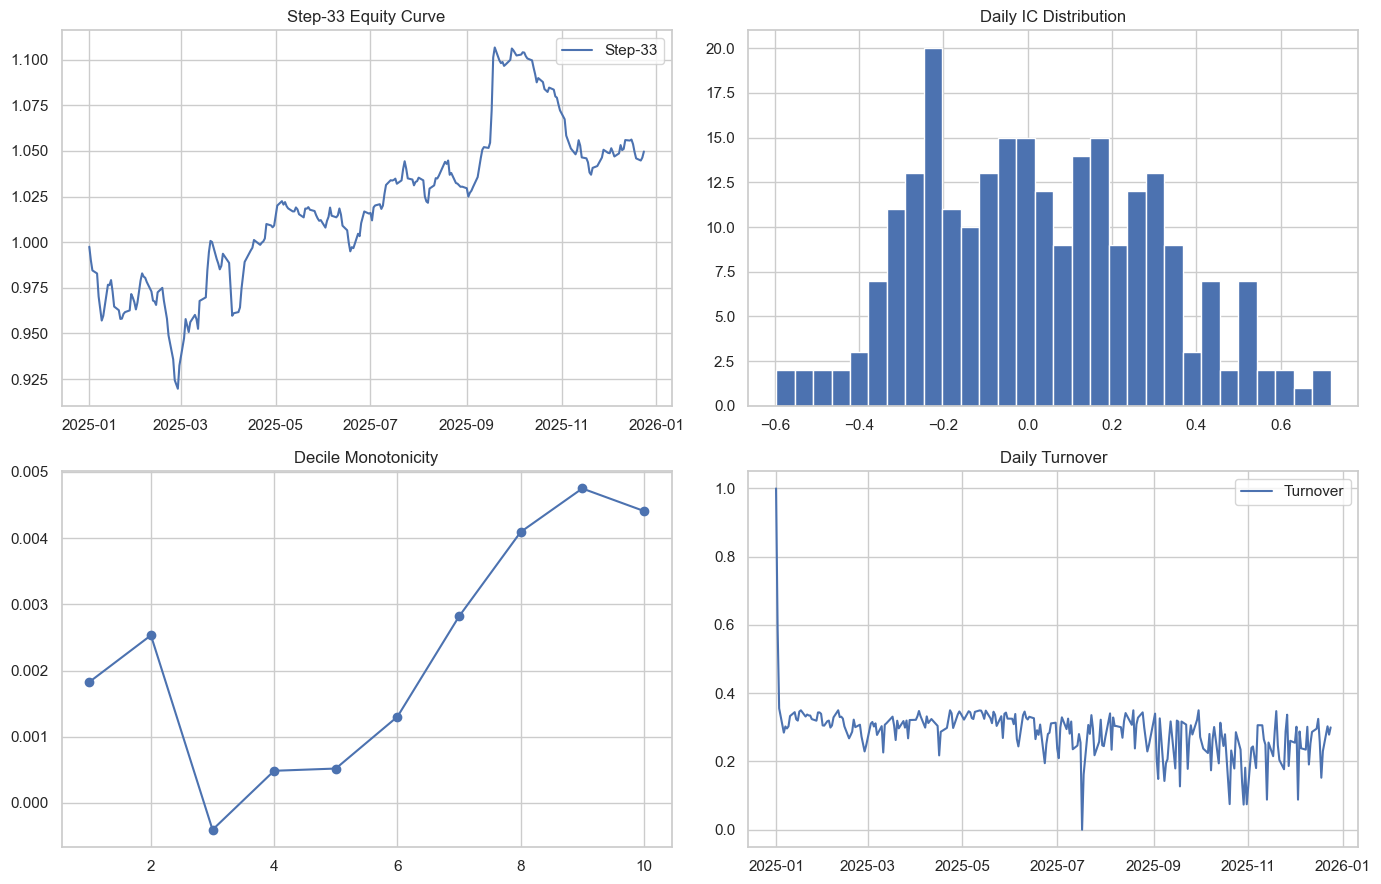

,Metric,Value
0,Total Return,0.049659
1,Annualized Return,0.050836
2,Annualized Volatility,0.085721
3,Sharpe Ratio,0.624138
4,Max Drawdown,-0.077968
5,Calmar Ratio,0.652009
6,Win Rate,0.473469
7,Average Turnover,0.288477
8,Average Gross Leverage,0.995918
9,Average Net Exposure,0.040952


,Metric,Value
0,Mean IC,0.026841
1,IC Std,0.273083
2,ICIR,0.098289
3,% Positive IC,0.497959


,Metric,Value
0,Top Decile Mean Return,0.004411
1,Bottom Decile Mean Return,0.001826
2,Decile Spread Mean,0.002584
3,Decile Monotonicity (Spearman),0.696970


,Cost_bps,TotalReturn,Sharpe
0,10,0.087409,1.048579
1,20,0.013215,0.200022
2,30,-0.055938,-0.646971
3,50,-0.180461,-2.334204
4,75,-0.313362,-4.425396
5,100,-0.424790,-6.489742


,Strategy,Total Return,Sharpe
0,Step-20 benchmark,5.612428,2.831832
1,Step-24 benchmark,0.111875,2.326499
2,Step-28 benchmark,2.857277,2.627988
3,Equal-weight benchmark,0.647524,1.797445
4,Long-only benchmark,1.982807,2.483545
5,NIFTY benchmark,NaN,NaN
6,Step-33 cost-aware,0.049659,0.624138


In [9]:
# Diagnostics plots
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

eq = (1 + daily_df["net_return"].fillna(0)).cumprod()
ax[0, 0].plot(daily_df["date"], eq, label="Step-33")
ax[0, 0].set_title("Step-33 Equity Curve")
ax[0, 0].legend()

ax[0, 1].hist(ic_df["ic"].dropna(), bins=30)
ax[0, 1].set_title("Daily IC Distribution")

if len(decile_avg):
    ax[1, 0].plot(decile_avg["decile"], decile_avg["actual_return"], marker="o")
ax[1, 0].set_title("Decile Monotonicity")

ax[1, 1].plot(daily_df["date"], daily_df["turnover"], label="Turnover")
ax[1, 1].set_title("Daily Turnover")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

display(summary_metrics(daily_df).round(6))
display(ic_summary.round(6))
display(decile_summary.round(6))
display(stress_df.round(6))
display(bench_df.round(6))
